# PROC BOX による救急外来の在院時間の可視化

## エグゼクティブサマリー

PROC BOXPLOT（PROC BOX のエイリアス）を用いて、3 つの診療サービス間で救急外来の在院時間を比較する病院オペレーション分析です。並べて表示した概略ボックスプロットにより、各サービスの中央値、四分位数、平均、および長期在院の外れ値を一目で把握できます。

シミュレートした 100 件の受診について、在院時間の中央値は **内科（Medicine）の 40.0 時間** から **外科（Surgery）の 50.4 時間**、さらに **外傷科（Trauma）の 60.5 時間** へと着実に上昇し、平均も同じ順序（41.6、54.6、62.8 時間）となっています。外科には上側ひげを超える 3 件の高い外れ値（最大 84.3 時間）があり、これらは最も多くのベッド時間を消費するボーディング（入院待機）ケースです。本ノートブックでは、この比較を 3 通りの方法で描画します。概略プロット、平均トレンドの重ね描き、そして横向きレイアウトです。

## データソース

すべてのデータは最初の DATA ステップ（`call streaminit(20260531)`）によってインラインで生成されます。外部やネットワークからの入力は使用しません。

**`ed_los`** — 救急外来受診 1 件につき 1 行（100 行）

| 変数 | 型 | 説明 |
|----------|------|-------------|
| `PatientID` | 数値 | 連番の受診識別子（1〜100） |
| `Department` | 文字(12) | 受け入れサービス：内科（Medicine）、外科（Surgery）、外傷科（Trauma） |
| `Severity` | 文字(8) | トリアージ重症度：Routine（約 55%）、Urgent（約 30%）、Critical（約 15%） |
| `LOS_Hours` | 数値 | 時間単位の在院時間。サービスと重症度に基づく平均に正規ノイズを加え、時折長期在院のショックが加わる（ラベルは「Length of Stay (hours)」） |

実現された構成は、内科 34 件 / 外科 36 件 / 外傷科 30 件の受診で、トリアージ重症度別では Routine 51 件 / Urgent 35 件 / Critical 14 件です。

# PROC BOX による救急外来の在院時間の可視化

在院時間（LOS）は、病院の救急外来において最も注意深く監視される運用指標の一つです。ベッドの空き状況、人員配置、患者のスループット、そして質のスコアを左右します。平均だけでは実態は見えません。オペレーションチームにとって重要なのは、在院時間の *ばらつき*、リソースを占有する *外れ値*、そして診療サービス間で分布がどのように異なるかです。

PROC BOX（PROC BOXPLOT のエイリアス）は、まさにこの比較のために作られています。並べて表示した箱ひげ図を描き、各グループの中央値、四分位数、平均、極端な観測値を示すため、アナリストは各サービスの LOS 分布の形状を一目で読み取ることができます。

本ノートブックでは、次のことを行います。

1. 100 観測の環境に適合する合成の救急外来受診データセットを生成します。
2. 部門別の LOS の概略ボックスプロットを、付随する統計量表とともに作成します。
3. `BOXCONNECT=MEAN` で平均トレンド線を重ね描きし、サービス間の勾配を明示します。
4. `HORIZONTAL` を使って同じ比較を横向きに描き直します。

## ステップ 1 — 合成の救急外来受診データを生成する

100 件の救急外来受診をシミュレートします。各患者は 3 つの診療サービス（内科、外科、外傷科）のいずれかと、トリアージ重症度（Routine、Urgent、Critical）に割り当てられます。在院時間は、サービス固有のベースラインから構築され、重症度の高い患者では上方にシフトし、正規分布のノイズが加わります。ごく一部の受診には追加の長期在院ショックが加わり、実際の救急外来データが常に示す重い右裾（ボーディング、入院ベッド待ちの入院）を模倣します。`call streaminit` の固定シードにより、データセットは完全に再現可能となります。

In [1]:
設定値 linesize=96;

データ ed_los;
   呼出 streaminit(20260531);
   長さ Department $ 24 Severity $ 12;
   繰返 PatientID = 1 から 100;
      d = rand('integer', 1, 3);
      もし d = 1 なら Department = '内科';
      他 もし d = 2 なら Department = '外科';
      他 Department = '外傷科';

      u = rand('uniform');
      もし u < 0.55 なら s = 1;
      他 もし u < 0.85 なら s = 2;
      他 s = 3;
      もし s = 1 なら Severity = '通常';
      他 もし s = 2 なら Severity = '緊急';
      他 Severity = '重篤';

      BASE = 24 + 10*d + 14*(s - 1);
      LOS_Hours = BASE + rand('normal', 0, 7);
      もし rand('uniform') < 0.06 なら
         LOS_Hours = LOS_Hours + rand('uniform', 40, 90);
      もし LOS_Hours < 2 なら LOS_Hours = 2;
      LOS_Hours = round(LOS_Hours, 0.1);
      出力;
   終了;
   削除 d u s BASE;
   見出 LOS_Hours = '在院時間（時間）';
実行;


NOTE: Option LINESIZE changed to 96.
NOTE: DATA ed_los


NOTE: Wrote ed_los (100 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds


## ステップ 2 — グループ変数でソートする

PROC BOX は、各グループの観測値が連続するように、グループ（横軸）変数がソートされていることを想定します。プロットの前に `Department` でソートします。

In [2]:
処理 並替 データ=ed_los;
   基準 Department;
実行;


NOTE: PROC SORT data=ed_los

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from ed_los.
NOTE: Wrote ed_los (100 rows, 4 columns).
NOTE: PROC SORT statement used.


## ステップ 3 — 概略ボックスプロット

中核となる分析です。`PLOT analysis-var * group-var` の構文により、部門ごとに 1 つのボックスを要求します。`BOXSTYLE=SCHEMATIC` は古典的な Tukey の概略プロットを生成します。ひげは四分位範囲の 1.5 倍以内の最も極端な観測値まで伸び、それを超える点はすべて外れ値として個別に描画されます。キャパシティを圧迫する長期在院ケースを見つけるのに最適です。

部門名は自明であるため、`NOHLABEL` は冗長な横軸ラベルを抑制します。プロットとともに、PROC BOXPLOT は各部門の N、最小値、四分位数、中央値、最大値、平均、標準偏差を示す統計量表を出力します。

                                         診療科別 救急外来在院時間                                          

                             診療科別 救急外来在院時間

                                     The BOXPLOT Procedure

Schematic Plots for 在院時間（時間）

診療科                   N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
内科                   34        16.30        33.90        45.65        52.80       102.60        46.94        19.70
外傷科                  30        46.10        54.53        62.50        74.95       134.40        67.48        20.78
外科                   36        29.30        46.90        50.70        60.02       142.80        60.04        25.18
------------------------------------------------------------------------------------------------------------



NOTE: Option TITLE changed to 診療科別 救急外来在院時間.
NOTE: PROC BOXPLOT data=ed_los

NOTE: ODS plot written: boxplot.spec.json


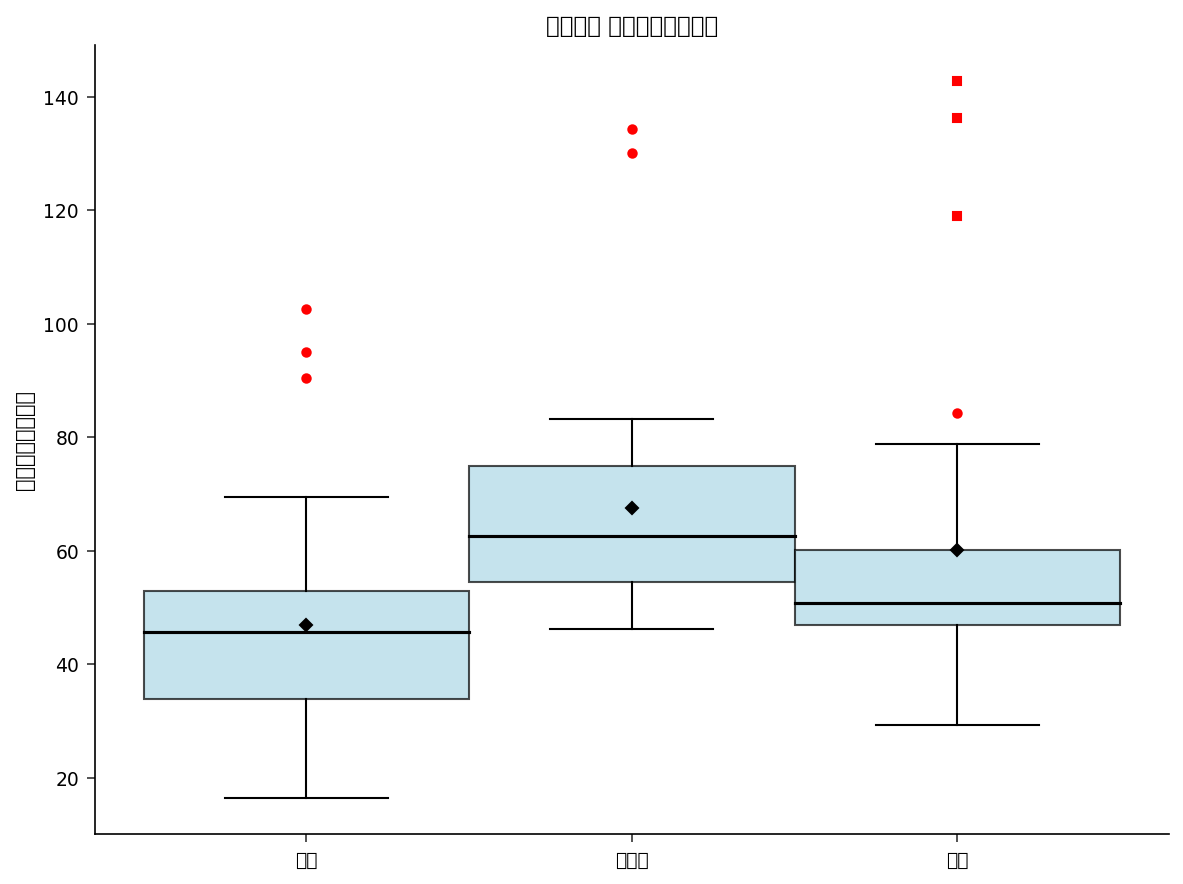

In [3]:
表題 '診療科別 救急外来在院時間';
処理 boxplot データ=ed_los;
   PLOT LOS_Hours*Department /
      boxstyle = schematic
      nohlabel;
   見出 Department = '診療科' LOS_Hours = '在院時間（時間）';
実行;

## ステップ 4 — 平均トレンド線を重ね描きする

サービス間の勾配を明示するために、`BOXCONNECT=MEAN` を追加します。すると PROC BOXPLOT は各ボックスの平均（ひし形のマーカー）を通る接続線を描き、3 つの別々の分布を 1 本の読み取りやすいトレンドにまとめます。部門は内科 → 外科 → 外傷科の順に並んでいるため、上昇する接続線は平均在院時間の増大を一筆で要約します。オペレーションダッシュボードにとって有用な手がかりです。

                                     診療科別 救急外来在院時間 − 平均トレンド                                     

                  診療科別 救急外来在院時間 − 平均トレンド

                                     The BOXPLOT Procedure

Schematic Plots for 在院時間（時間）

診療科                   N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
内科                   34        16.30        33.90        45.65        52.80       102.60        46.94        19.70
外傷科                  30        46.10        54.53        62.50        74.95       134.40        67.48        20.78
外科                   36        29.30        46.90        50.70        60.02       142.80        60.04        25.18
------------------------------------------------------------------------------------------------------------



NOTE: Option TITLE changed to 診療科別 救急外来在院時間 − 平均トレンド.
NOTE: PROC BOXPLOT data=ed_los

NOTE: ODS plot written: boxplot.spec.json


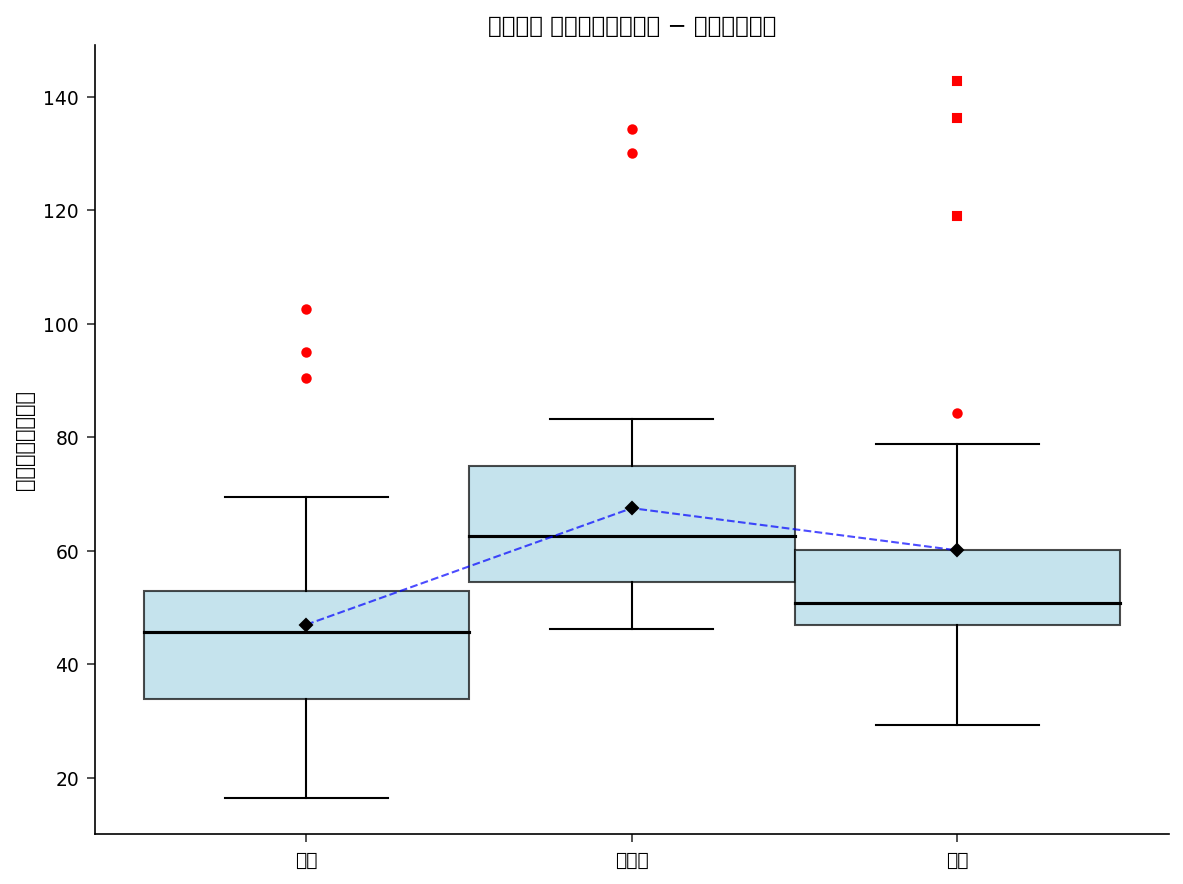

In [4]:
表題 '診療科別 救急外来在院時間 − 平均トレンド';
処理 boxplot データ=ed_los;
   PLOT LOS_Hours*Department /
      boxstyle    = schematic
      boxconnect  = mean
      nohlabel;
   見出 Department = '診療科' LOS_Hours = '在院時間（時間）';
実行;

## ステップ 5 — 横向きレイアウト

同じ比較を横向きにしても自然に読み取れます。`HORIZONTAL` を追加すると軸が入れ替わり、応答変数を x 軸にとってボックスが左から右へ並びます。このレイアウトは、サービス名が長い場合や数が多い場合によりよくスケールし、多くのオペレーションダッシュボードで好まれます。統計量は縦向きの表示と同一で、変わるのは向きだけです。

                                      診療科別 救急外来在院時間 − 横向き                                       

                      診療科別 救急外来在院時間 − 横向き

                                     The BOXPLOT Procedure

Schematic Plots for 在院時間（時間）

診療科                   N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
内科                   34        16.30        33.90        45.65        52.80       102.60        46.94        19.70
外傷科                  30        46.10        54.53        62.50        74.95       134.40        67.48        20.78
外科                   36        29.30        46.90        50.70        60.02       142.80        60.04        25.18
------------------------------------------------------------------------------------------------------------



NOTE: Option TITLE changed to 診療科別 救急外来在院時間 − 横向き.
NOTE: PROC BOXPLOT data=ed_los

NOTE: ODS plot written: boxplot.spec.json


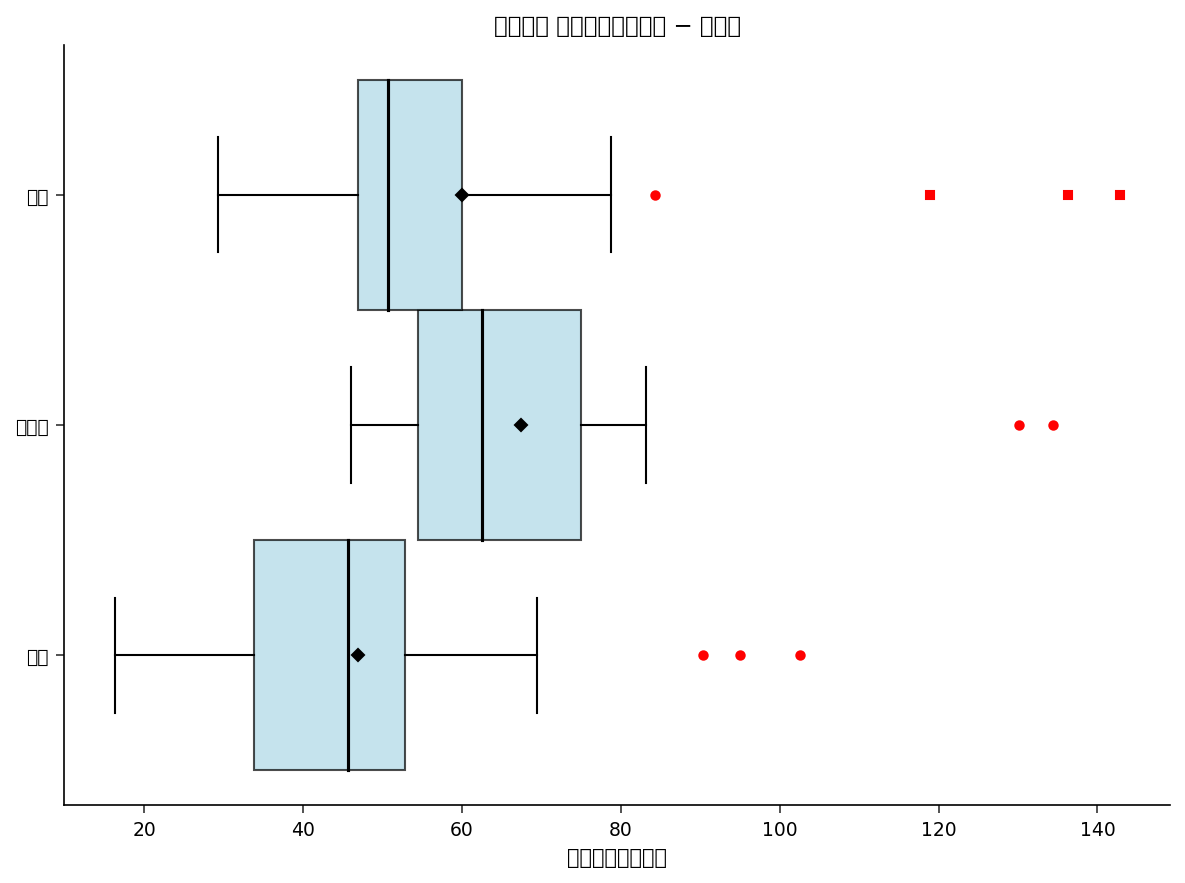

In [5]:
表題 '診療科別 救急外来在院時間 − 横向き';
処理 boxplot データ=ed_los;
   PLOT LOS_Hours*Department /
      boxstyle   = schematic
      horizontal
      nohlabel;
   見出 Department = '診療科' LOS_Hours = '在院時間（時間）';
実行;

## 結果の解釈

ボックスプロットと付随する統計量表は、生の LOS データを運用上実行可能な全体像へと変換します。

- **明確なサービス勾配。** 在院時間の中央値は 3 つのサービスにわたって単調に上昇します。**内科 40.0 時間 → 外科 50.4 時間 → 外傷科 60.5 時間**。平均も同じことを示し（41.6、54.6、62.8 時間）、ステップ 4 の `BOXCONNECT=MEAN` 線はその増大を 1 本の上昇トレンドとして描きます。外傷科の患者は平均して内科の患者よりおよそ 50% 長く在院します。

- **ばらつきは中央値と同じくらい重要。** 四分位範囲（ボックスの高さ）は内科で最も広く（Q1 32.8 時間から Q3 51.2 時間、18.3 時間の広がり）、外傷科で最も狭くなっています（Q1 54.5 時間から Q3 68.5 時間、14.0 時間の広がり）。したがって内科は最も在院時間が短いサービスであるだけでなく、最も予測しにくいサービスでもあり、この性質がベッド管理の予測を難しくします。

- **外れ値がボーディングケースを示す。** 概略のひげは 1.5 × IQR で止まるため、外科の上側ひげを超える 3 つの赤い点（ピークは 84.3 時間）は真の長期在院受診として際立ちます。まさに不釣り合いに多くのベッド時間を消費するボーディングケースです。このサンプルでは、内科と外傷科にはひげを超える点はありません。

- **範囲がキャパシティ計画の物語を語る。** 観測された在院時間は、内科で 16.3〜69.5 時間、外科で 29.3〜84.3 時間、外傷科で 46.1〜83.2 時間にわたります。外傷科は短い在院を決して生じさせません（その最小値 46.1 時間は内科の中央値を上回ります）。これは最もリソースを要するサービスに対してオペレーションチームが予想する通りの結果です。

これらの表示を組み合わせることで、救急外来のリーダーシップチームは、人員配置とキャパシティ計画のための、分布を考慮した根拠のある基盤を得られます。部門ごとの平均 LOS だけを比較するよりもはるかに多くの情報が得られます。